In [1]:
# ============================================================
# Imports & Configuration
# ============================================================


import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.operators import MeasurementOperator
from src.admm import admm_solve
from src.svt import effective_rank
from src.metrics import relative_error, psnr, ssim
from config import (SHEPP_LOGAN_PATH, IMAGE_SIZE,
                    N_MEASUREMENTS, RANDOM_SEED, RHO, MAX_ITER, TOL)

%matplotlib inline
plt.rcParams['figure.dpi']  =  120
plt.rcParams['image.cmap']  =  'gray'

# 1. Load and inspect the Shepp-Logan phantom
The Shepp-Logan phantom is a standard medical imaging test image. Unlike the toy problem, 
it is not exactly low-rank — its singular values decay smoothly. We characterise this decay 
to understand how well the low-rank model applies.

In [2]:
X_true  =  np.load(SHEPP_LOGAN_PATH)

sigma  =  np.linalg.svd(X_true, compute_uv = False)
rank_full  =  np.linalg.matrix_rank(X_true)
eff_rank  =  np.sum(sigma > sigma[0] * 1e-3)

print(f"Image shape     : {X_true.shape}")
print(f"Value range     : [{X_true.min():.4f}, {X_true.max():.4f}]")
print(f"Full rank       : {rank_full}")
print(f"Effective rank  : {eff_rank}  (singular values > 0.1% of largest)")
print(f"Measurements m  : {N_MEASUREMENTS}")
print(f"Pixels n²       : {IMAGE_SIZE**2}")
print(f"Sampling ratio  : {N_MEASUREMENTS/IMAGE_SIZE**2:.4f}  "
      f"({100*N_MEASUREMENTS/IMAGE_SIZE**2:.1f}%)")

total_energy  =  np.sum(sigma**2)
print("\nEnergy captured by top-k singular values:")
for k in [5, 10, 20, 30, 50]:
    energy  =  np.sum(sigma[:k]**2) / total_energy
    print(f"  top-{k:3d} : {energy*100:.1f}%")

Image shape     : (128, 128)
Value range     : [0.0000, 1.0000]
Full rank       : 74
Effective rank  : 67  (singular values > 0.1% of largest)
Measurements m  : 5000
Pixels n²       : 16384
Sampling ratio  : 0.3052  (30.5%)

Energy captured by top-k singular values:
  top-  5 : 77.0%
  top- 10 : 91.7%
  top- 20 : 98.8%
  top- 30 : 99.8%
  top- 50 : 100.0%


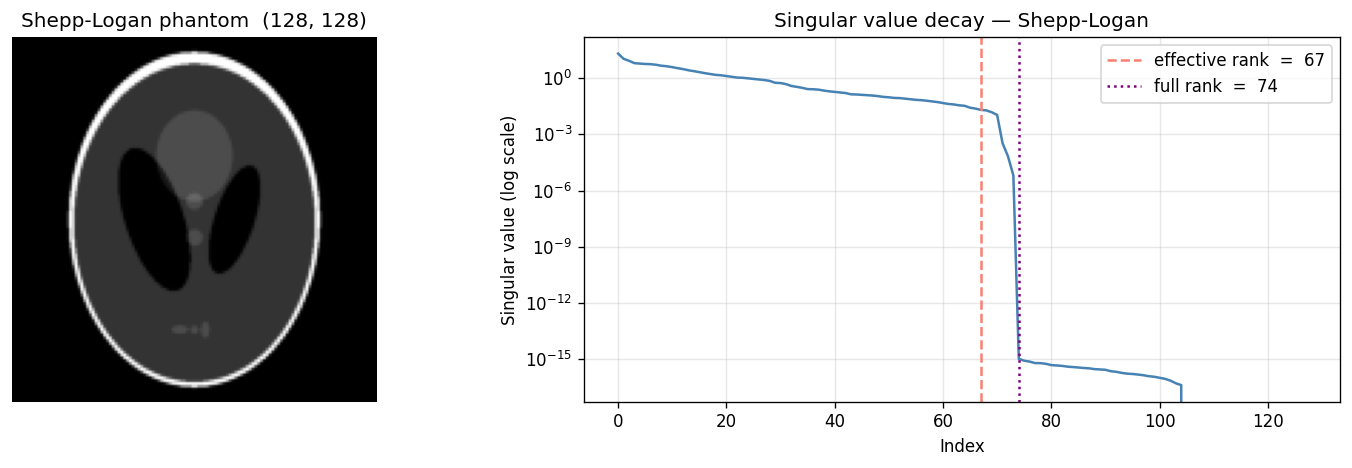

In [3]:
fig, axes  =  plt.subplots(1, 2, figsize = (13, 4))

axes[0].imshow(X_true)
axes[0].set_title(f"Shepp-Logan phantom  {X_true.shape}")
axes[0].axis('off')

axes[1].semilogy(sigma, color = 'steelblue', linewidth = 1.5)
axes[1].axvline(x = eff_rank, color = 'salmon', linestyle = '--',
                label = f'effective rank  =  {eff_rank}')
axes[1].axvline(x = rank_full, color = 'purple', linestyle = ':',
                label = f'full rank  =  {rank_full}')
axes[1].set_title("Singular value decay — Shepp-Logan")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Singular value (log scale)")
axes[1].legend()
axes[1].grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

# 2. Run the solver

In [4]:
op =  MeasurementOperator(n = IMAGE_SIZE, m = N_MEASUREMENTS, seed = RANDOM_SEED)
y =  op.measure(X_true)

print("Running solver...")
result  =  admm_solve(op, y, rho = RHO, max_iter = MAX_ITER, tol = TOL,
                    X_true = X_true, verbose = True)

Running solver...
  Iter        Primal          Dual    Rank      RelErr
-------------------------------------------------------
     1     16.640665     24.960998       0    1.000000
     2     10.883693      5.127261     107    0.856087
     3      0.943856      3.703107      89    0.730259
     4      0.702909      3.029538      80    0.691718
     5      0.603189      2.564035      76    0.658305
    51      0.010382      0.043618      50    0.367163
   101      0.000262      0.001337      50    0.362542
   151      0.000010      0.000055      50    0.362407

Converged at iteration 179
Primal residual: 1.82e-06
Dual residual: 9.87e-06
Final rank: 50
Relative error: 0.362403


# 3. Visual recovery check

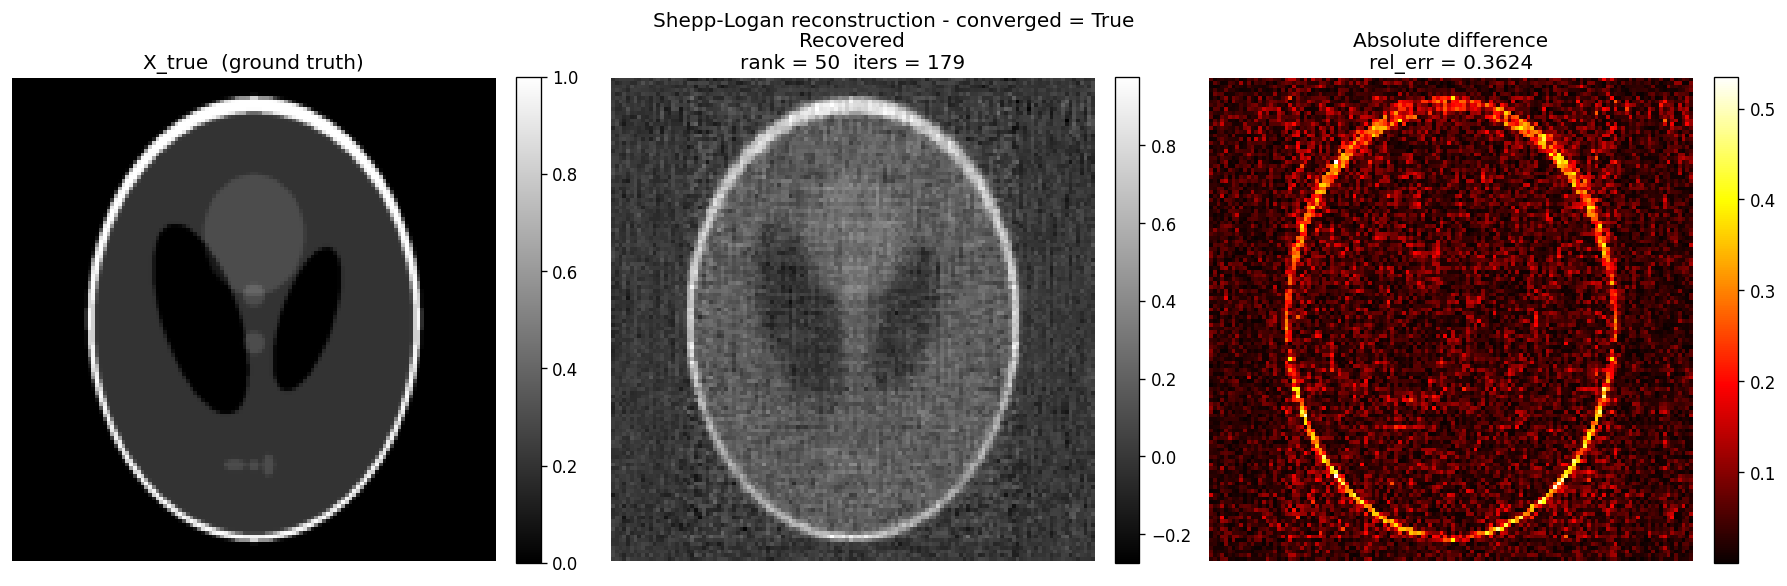

In [5]:
fig, axes  =  plt.subplots(1, 3, figsize = (15, 5))

im0  =  axes[0].imshow(X_true)
axes[0].set_title("X_true  (ground truth)")
axes[0].axis('off')
plt.colorbar(im0, ax = axes[0], fraction = 0.046, pad = 0.04)

im1  =  axes[1].imshow(result.X)
axes[1].set_title(f"Recovered\nrank = {effective_rank(result.X)}  "
                  f"iters = {result.n_iters}")
axes[1].axis('off')
plt.colorbar(im1, ax = axes[1], fraction = 0.046, pad = 0.04)

diff =  np.abs(result.X - X_true)
rel_err =  np.linalg.norm(result.X - X_true, 'fro') / np.linalg.norm(X_true, 'fro')
im2  =  axes[2].imshow(diff, cmap = 'hot')
axes[2].set_title(f"Absolute difference\nrel_err = {rel_err:.4f}")
axes[2].axis('off')
plt.colorbar(im2, ax = axes[2], fraction = 0.046, pad = 0.04)

plt.suptitle(f"Shepp-Logan reconstruction - converged = {result.converged}", fontsize = 12)
plt.tight_layout()
plt.show()

# 4. Convergence diagnostics

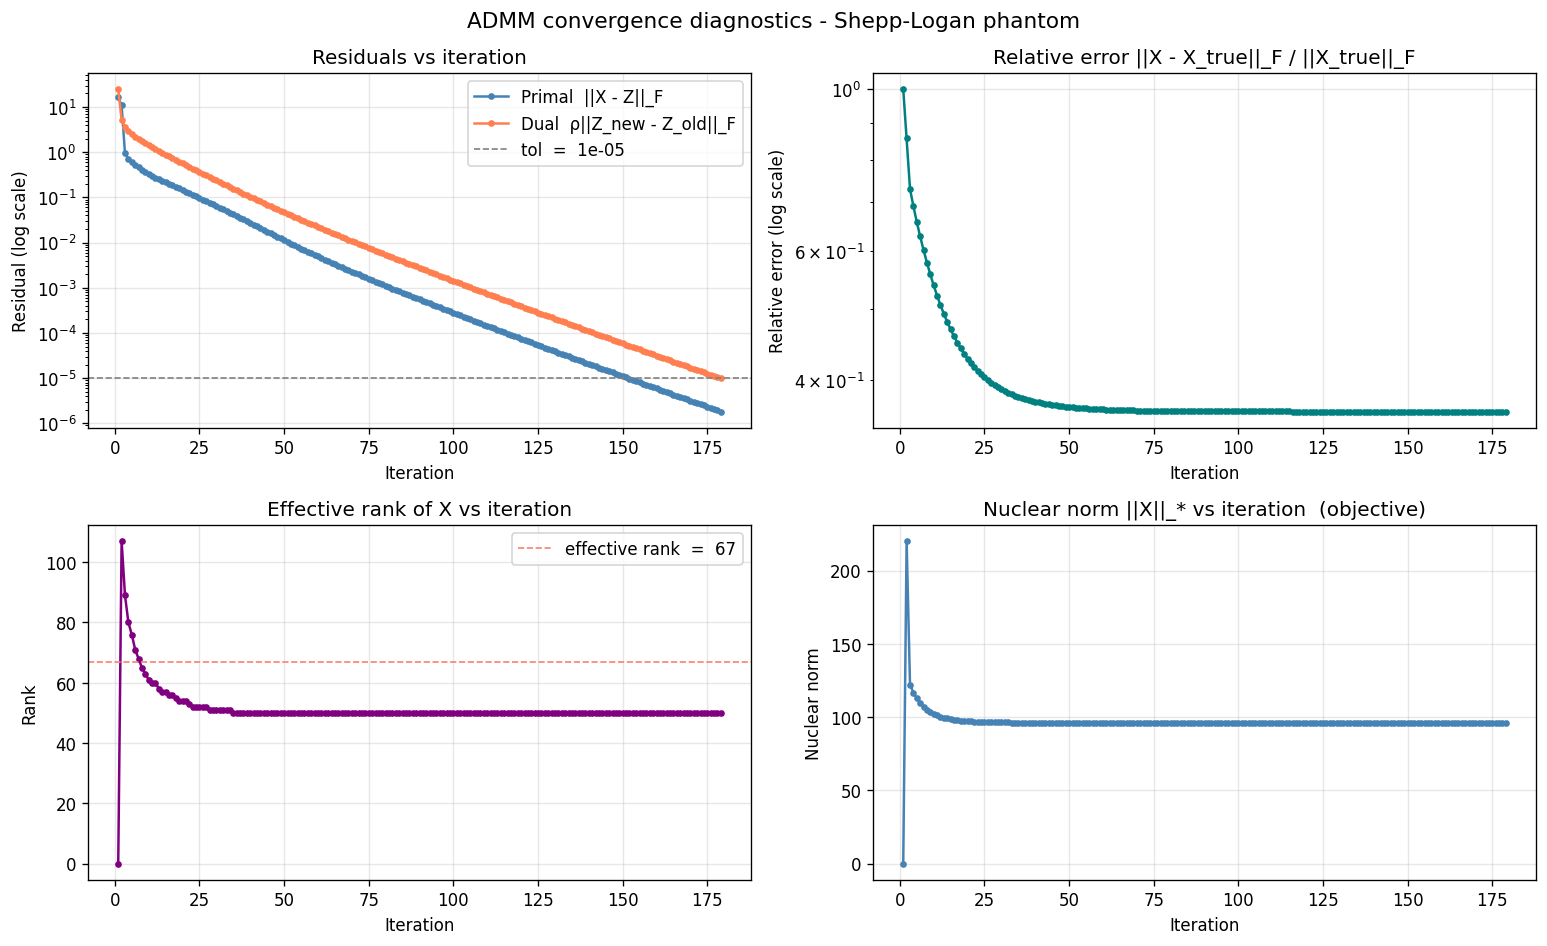

In [6]:
h      =  result.history
iters  =  range(1, result.n_iters + 1)

fig, axes  =  plt.subplots(2, 2, figsize = (13, 8))

# Primal and dual residuals
axes[0, 0].semilogy(iters, h.primal_residuals, color = 'steelblue',
                    linewidth = 1.5, label = 'Primal  ||X - Z||_F', marker = '.')
axes[0, 0].semilogy(iters, h.dual_residuals, color = 'coral',
                    linewidth = 1.5, label = 'Dual  ρ||Z_new - Z_old||_F', marker = '.')
axes[0, 0].axhline(y = TOL, color = 'gray', linestyle = '--', linewidth = 1,
                   label = f'tol  =  {TOL}')
axes[0, 0].set_title("Residuals vs iteration")
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Residual (log scale)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha = 0.3)

# Relative error vs X_true
axes[0, 1].semilogy(iters, h.rel_errors, color = 'teal', linewidth = 1.5, marker = '.')
axes[0, 1].set_title("Relative error ||X - X_true||_F / ||X_true||_F")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Relative error (log scale)")
axes[0, 1].grid(True, alpha = 0.3)

# Rank evolution
axes[1, 0].plot(iters, h.ranks, color = 'purple', linewidth = 1.5, marker = '.')
axes[1, 0].axhline(y = eff_rank, color = 'salmon', linestyle = '--', linewidth = 1,
                   label = f'effective rank  =  {eff_rank}')
axes[1, 0].set_title("Effective rank of X vs iteration")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Rank")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha = 0.3)

# Nuclear norm (objective value)
axes[1, 1].plot(iters, h.objective_values, color = 'steelblue', linewidth = 1.5, marker = '.')
axes[1, 1].set_title("Nuclear norm ||X||_* vs iteration  (objective)")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Nuclear norm")
axes[1, 1].grid(True, alpha = 0.3)

plt.suptitle("ADMM convergence diagnostics - Shepp-Logan phantom", fontsize = 13)
plt.tight_layout()
plt.show()

# 5. Singular value recovery check
Compare the singular value spectrum of the recovered image against the ground truth.
Because the Shepp-Logan is not exactly low-rank, we expect approximate but not perfect 
agreement in the tail.

True singular values (top 10)     : [20.5054 10.8276  8.4819  6.3146  6.0251  5.7149  5.5736  5.1904  4.6083
  4.311 ]
Recovered singular values (top 10): [19.0193  9.2519  6.8119  4.9301  4.7112  4.5771  4.2478  3.9816  3.3252
  2.9554]

Final recovered rank (tol = 1e-3)   : 50
Final recovered rank (tol = 1e-6)   : 50


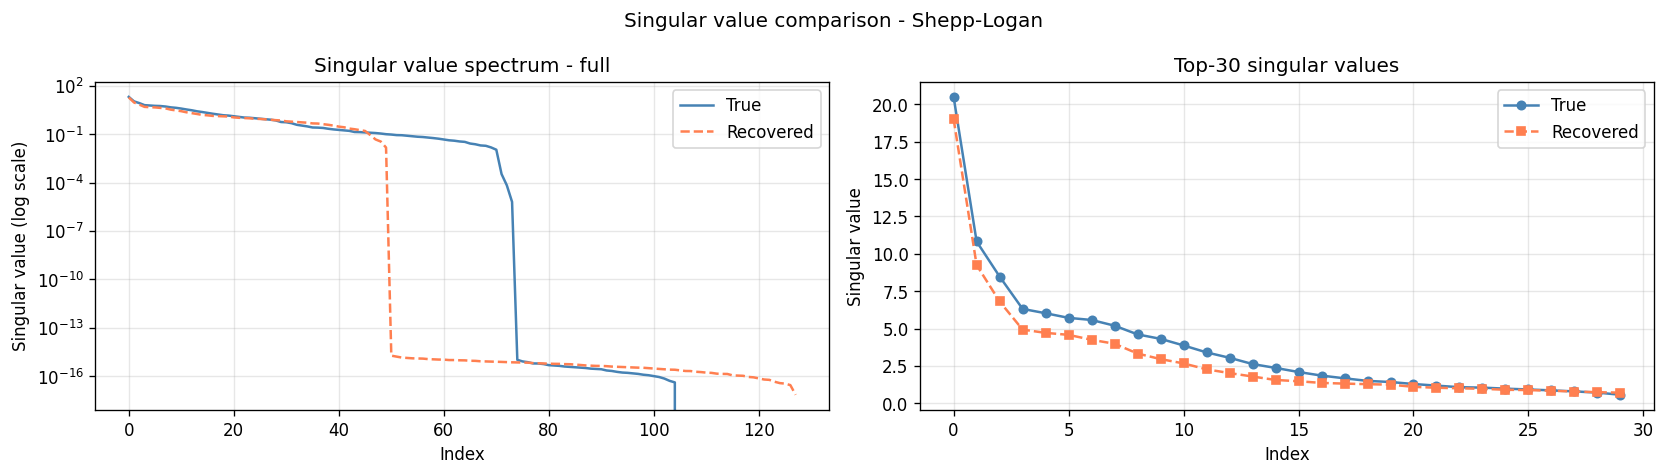

In [7]:
sigma_recovered = np.linalg.svd(result.X, compute_uv = False)

print(f"True singular values (top 10)     : {np.round(sigma[:10], 4)}")
print(f"Recovered singular values (top 10): {np.round(sigma_recovered[:10], 4)}")
print(f"\nFinal recovered rank (tol = 1e-3)   : {effective_rank(result.X, tol = 1e-3)}")
print(f"Final recovered rank (tol = 1e-6)   : {effective_rank(result.X, tol = 1e-6)}")

fig, axes  =  plt.subplots(1, 2, figsize = (14, 4))

#Full spectrum
axes[0].semilogy(sigma, color = 'steelblue', linewidth = 1.5, label = 'True')
axes[0].semilogy(sigma_recovered, color = 'coral', linestyle = '--',
                 linewidth = 1.5, label = 'Recovered')
axes[0].set_title("Singular value spectrum - full")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Singular value (log scale)")
axes[0].legend()
axes[0].grid(True, alpha = 0.3)

#Top-30 
top  =  30
axes[1].plot(sigma[:top], 'o-', color = 'steelblue', linewidth = 1.5,
             markersize = 5, label = 'True')
axes[1].plot(sigma_recovered[:top], 's--', color = 'coral', linewidth = 1.5,
             markersize = 5, label = 'Recovered')
axes[1].set_title(f"Top-{top} singular values")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Singular value")
axes[1].legend()
axes[1].grid(True, alpha = 0.3)

plt.suptitle("Singular value comparison - Shepp-Logan", fontsize = 12)
plt.tight_layout()
plt.show()

# 6. Sampling ratio sweep
How do all three metrics change as we give the solver more or fewer measurements?

In [8]:
ratios  =  [0.05, 0.10, 0.20, 0.30, 0.50]
sweep   =  {'rel_err': [], 'psnr': [], 'ssim': [], 'rank': []}

print(f"{'ratio':>6}  {'m':>6}  {'rel_err':>9}  {'PSNR':>8}  {'SSIM':>7}  {'rank':>6}  {'conv':>6}")
print("-" * 60)

for ratio in ratios:
    m_r   =  max(10, int(ratio * IMAGE_SIZE**2))
    op_r  =  MeasurementOperator(n = IMAGE_SIZE, m = m_r, seed = RANDOM_SEED)
    y_r   =  op_r.measure(X_true)
    res   =  admm_solve(op_r, y_r, rho = RHO, max_iter = MAX_ITER, tol = TOL, verbose = False)

    re  =  relative_error(res.X, X_true)
    p   =  psnr(res.X, X_true)
    s   =  ssim(res.X, X_true)
    rk  =  effective_rank(res.X)
    sweep['rel_err'].append(re)
    sweep['psnr'].append(p)
    sweep['ssim'].append(s)
    sweep['rank'].append(rk)
    print(f"{ratio:>6.2f}  {m_r:>6d}  {re:>9.5f}  {p:>8.2f}  {s:>7.4f}  "
          f"{rk:>6d}  {str(res.converged):>6}")

 ratio       m    rel_err      PSNR     SSIM    rank    conv
------------------------------------------------------------
  0.05     819    0.87945     14.19   0.0809      17    True
  0.10    1638    0.74936     15.54   0.1203      26    True
  0.20    3276    0.53927     18.45   0.2310      39    True
  0.30    4915    0.36839     21.84   0.3342      50    True
  0.50    8192    0.15154     29.79   0.6002      71    True


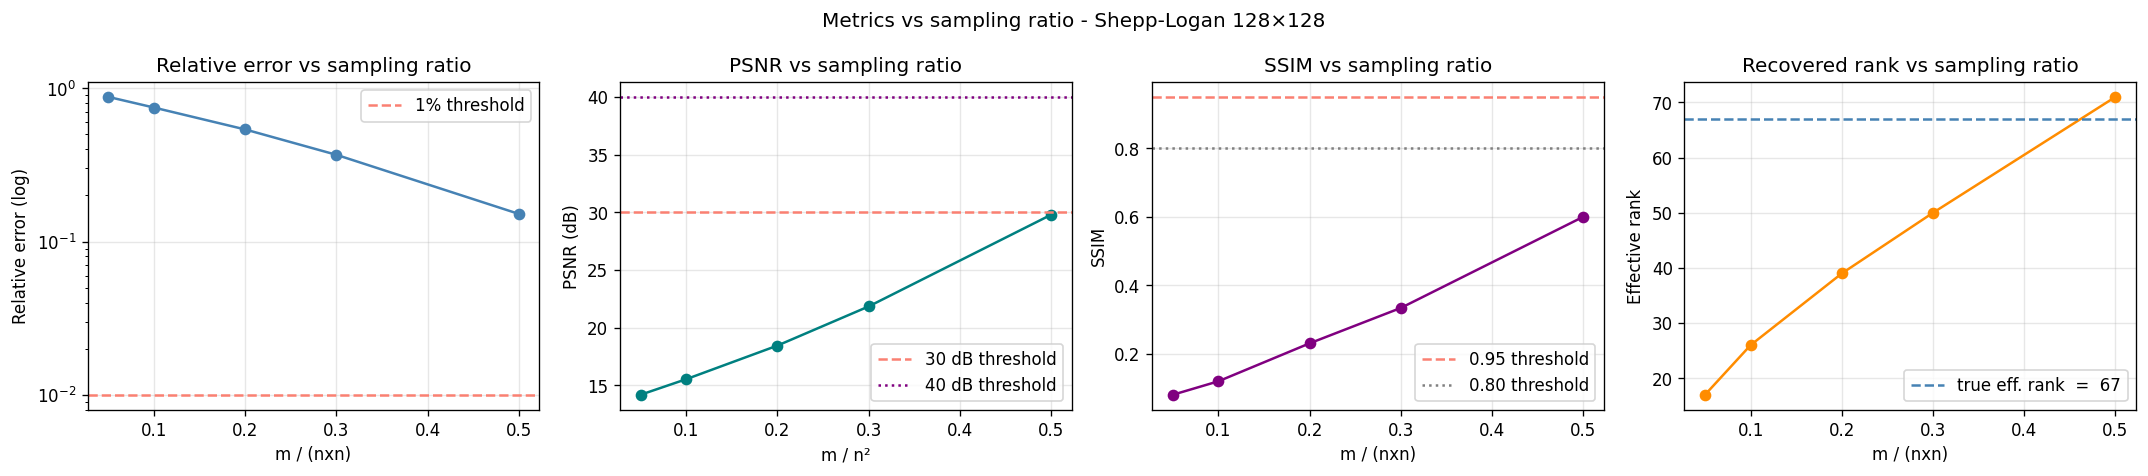

In [9]:
fig, axes  =  plt.subplots(1, 4, figsize = (18, 4))

axes[0].semilogy(ratios, sweep['rel_err'], 'o-', color = 'steelblue',
                 linewidth = 1.5, markersize = 6)
axes[0].axhline(y = 1e-2, color = 'salmon', linestyle = '--', label = '1% threshold')
axes[0].set_title("Relative error vs sampling ratio")
axes[0].set_xlabel("m / (nxn)")
axes[0].set_ylabel("Relative error (log)")
axes[0].legend()
axes[0].grid(True, alpha = 0.3)

axes[1].plot(ratios, sweep['psnr'], 'o-', color = 'teal',
             linewidth = 1.5, markersize = 6)
axes[1].axhline(y = 30, color = 'salmon', linestyle = '--', label = '30 dB threshold')
axes[1].axhline(y = 40, color = 'purple', linestyle = ':', label = '40 dB threshold')
axes[1].set_title("PSNR vs sampling ratio")
axes[1].set_xlabel("m / n²")
axes[1].set_ylabel("PSNR (dB)")
axes[1].legend()
axes[1].grid(True, alpha = 0.3)

axes[2].plot(ratios, sweep['ssim'], 'o-', color = 'purple',
             linewidth = 1.5, markersize = 6)
axes[2].axhline(y = 0.95, color = 'salmon', linestyle = '--', label = '0.95 threshold')
axes[2].axhline(y = 0.80, color = 'gray', linestyle = ':', label = '0.80 threshold')
axes[2].set_title("SSIM vs sampling ratio")
axes[2].set_xlabel("m / (nxn)")
axes[2].set_ylabel("SSIM")
axes[2].legend()
axes[2].grid(True, alpha = 0.3)

axes[3].plot(ratios, sweep['rank'], 'o-', color = 'darkorange',
             linewidth = 1.5, markersize = 6)
axes[3].axhline(y = eff_rank, color = 'steelblue', linestyle = '--',
                label = f'true eff. rank  =  {eff_rank}')
axes[3].set_title("Recovered rank vs sampling ratio")
axes[3].set_xlabel("m / (nxn)")
axes[3].set_ylabel("Effective rank")
axes[3].legend()
axes[3].grid(True, alpha = 0.3)

plt.suptitle(f"Metrics vs sampling ratio - Shepp-Logan {IMAGE_SIZE}×{IMAGE_SIZE}",
             fontsize = 12)
plt.tight_layout()
plt.show()

# 7. $\rho$ (rho) sensitivity analysis

In [10]:
rho_values  =  [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

rho_results  =  []
print(f"{'rho':>8}  {'iters':>7}  {'rel_err':>10}  {'PSNR':>8}  {'SSIM':>7}  {'conv':>6}")
print("-" * 55)

for rho_val in rho_values:
    res  =  admm_solve(op, y, rho = rho_val, max_iter = MAX_ITER, tol = TOL,
                     X_true = X_true, verbose = False)
    re  =  relative_error(res.X, X_true)
    p   =  psnr(res.X, X_true)
    s   =  ssim(res.X, X_true)
    rho_results.append((rho_val, res.n_iters, re, p, s, res.converged, res.history))
    print(f"{rho_val:>8.3f}  {res.n_iters:>7d}  {re:>10.6f}  {p:>8.2f}  "
          f"{s:>7.4f}  {str(res.converged):>6}")

     rho    iters     rel_err      PSNR     SSIM    conv
-------------------------------------------------------
   0.010     1000    0.361694     22.00   0.3389   False
   0.100      755    0.362402     21.99   0.3386    True
   0.500      150    0.362402     21.99   0.3386    True
   1.000      109    0.362402     21.99   0.3386    True
   5.000      616    0.362403     21.99   0.3386    True
  10.000     1000    0.362410     21.99   0.3386   False


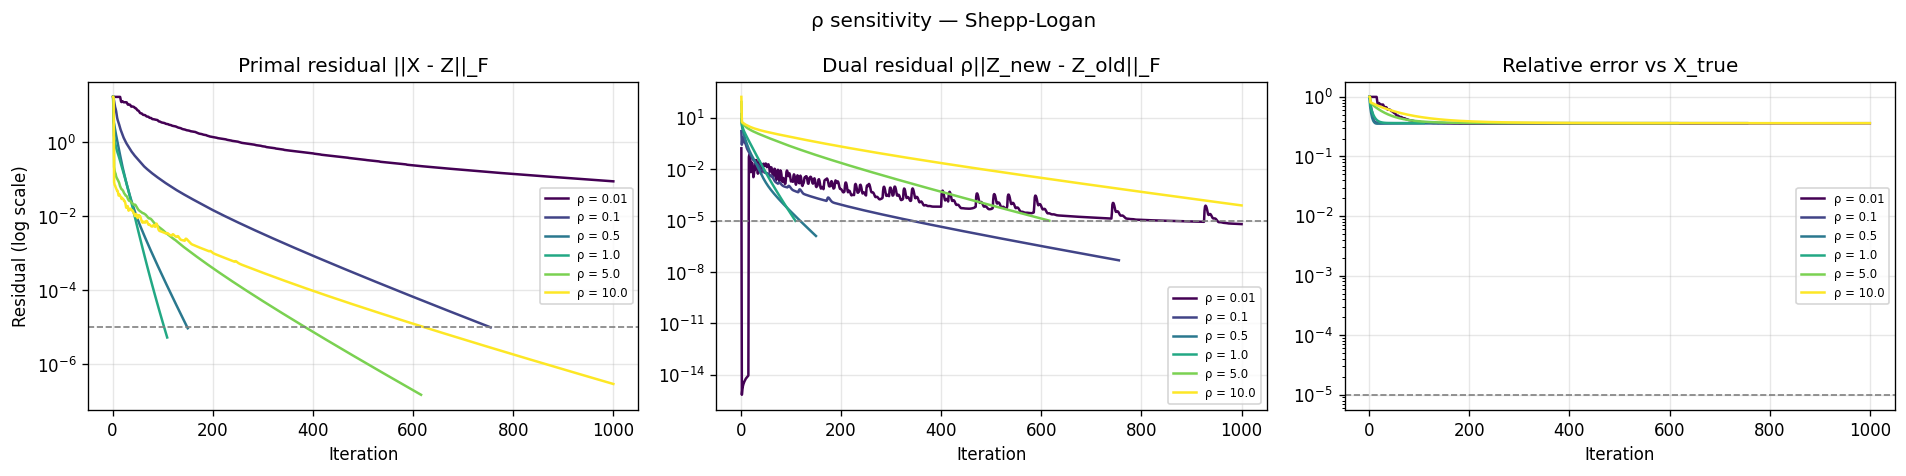

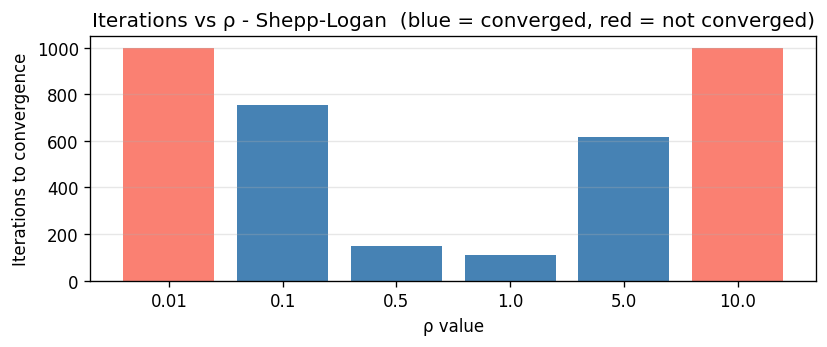

In [11]:
fig, axes  =  plt.subplots(1, 3, figsize = (16, 4))
colors  =  plt.cm.viridis(np.linspace(0, 1, len(rho_values)))

for i, (rho_val, n_iters, re, p, s, conv, hist) in enumerate(rho_results):
    iters_r  =  range(1, n_iters + 1)
    axes[0].semilogy(iters_r, hist.primal_residuals, color = colors[i],
                     linewidth = 1.5, label = f'ρ = {rho_val}')
    axes[1].semilogy(iters_r, hist.dual_residuals, color = colors[i],
                     linewidth = 1.5, label = f'ρ = {rho_val}')
    if hist.rel_errors:
        axes[2].semilogy(iters_r, hist.rel_errors, color = colors[i],
                         linewidth = 1.5, label = f'ρ = {rho_val}')

for ax in axes:
    ax.axhline(y = TOL, color = 'gray', linestyle = '--', linewidth = 1)
    ax.legend(fontsize = 7)
    ax.grid(True, alpha = 0.3)
    ax.set_xlabel("Iteration")

axes[0].set_title("Primal residual ||X - Z||_F")
axes[0].set_ylabel("Residual (log scale)")
axes[1].set_title("Dual residual ρ||Z_new - Z_old||_F")
axes[2].set_title("Relative error vs X_true")

plt.suptitle("ρ sensitivity - Shepp-Logan", fontsize = 12)
plt.tight_layout()
plt.show()

#Summary: iterations to convergence vs rho
fig, ax  =  plt.subplots(figsize = (7, 3))
iters_list  =  [r[1] for r in rho_results]
ax.bar([str(r[0]) for r in rho_results], iters_list,
       color = ['steelblue' if r[5] else 'salmon' for r in rho_results])
ax.set_xlabel("ρ value")
ax.set_ylabel("Iterations to convergence")
ax.set_title("Iterations vs ρ - Shepp-Logan  (blue = converged, red = not converged)")
ax.grid(True, alpha = 0.3, axis = 'y')
plt.tight_layout()
plt.show()